In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from pyproj import Proj, Transformer
from scipy.interpolate import griddata
import xeofs as xe
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs

crs = ccrs.PlateCarree()
import warnings
import os

warnings.filterwarnings('ignore')
from matplotlib.ticker import MultipleLocator


In [3]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/Data/'
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

# ice_vel_ds = xr.open_dataset(path + 'ice_vels_no_nan_ds.nc')
ice_vels_ds_melt_and_mean = xr.open_dataset(path + 'ice_vels_ds_melt_and_mean.nc')
#dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
ssh_regridded_ds = xr.open_dataset(path + 'regridded_ssh2icevel_ds.nc')
bedmap3 = xr.open_dataset(path_ds + 'bedmap3.nc')



In [4]:
print(ssh_regridded_ds['SSH_regridded'].shape)
print(ssh_regridded_ds['time'][2])
print(ssh_regridded_ds['time'][-1])

(61, 2916, 2916)
<xarray.DataArray 'time' ()> Size: 8B
array('2003-03-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2003-03-01
<xarray.DataArray 'time' ()> Size: 8B
array('2017-09-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2017-09-01


In [5]:
print(ice_vels_ds_melt_and_mean['melt'].isel(time=6))

<xarray.DataArray 'melt' (y: 2916, x: 2916)> Size: 34MB
[8503056 values with dtype=float32]
Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
    time     datetime64[ns] 8B 2004-09-01
Dimensions without coordinates: y, x


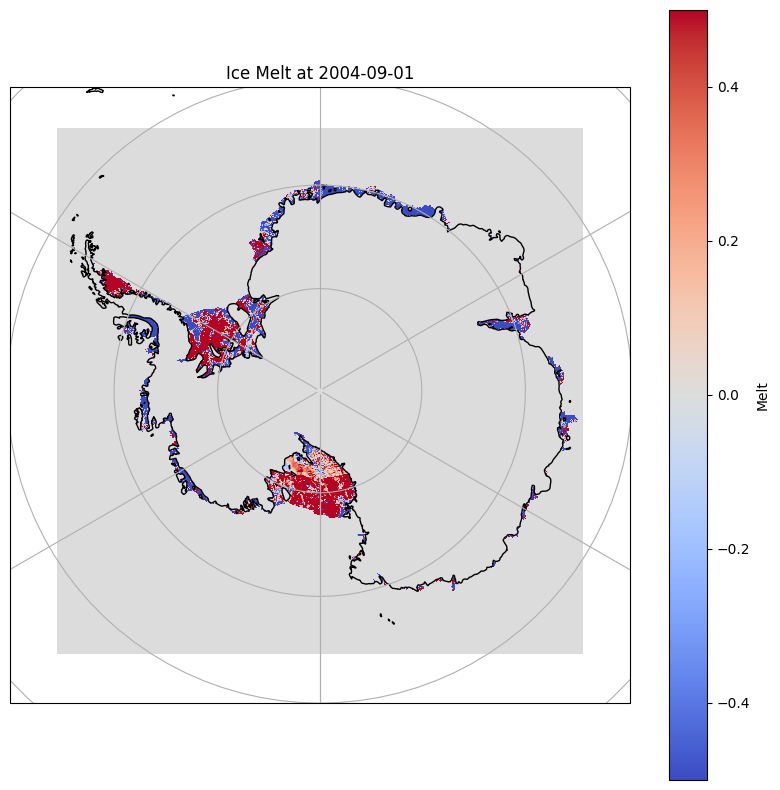

In [9]:
# Extract data from each dataset
data_1 = ice_vels_ds_melt_and_mean['melt'].isel(time=6)
lat_1 = ice_vels_ds_melt_and_mean['lat']
lon_1 = ice_vels_ds_melt_and_mean['lon']

# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-0.5, vmax=0.5)
ax1.set_title("Ice Melt at 2004-09-01")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

In [18]:
print(bedmap3['x'][5]-bedmap3['x'][4])
print(bedmap3['y'][1500]-bedmap3['y'][1499])

<xarray.DataArray 'x' ()> Size: 4B
array(500., dtype=float32)
Attributes:
    units:          meters
    standard_name:  projection_x_coordinate
    long_name:      X coordinate in projected system (EPSG:3031)
<xarray.DataArray 'y' ()> Size: 4B
array(-500., dtype=float32)
Attributes:
    units:          meters
    standard_name:  projection_y_coordinate
    long_name:      Y coordinate in projected system (EPSG:3031)


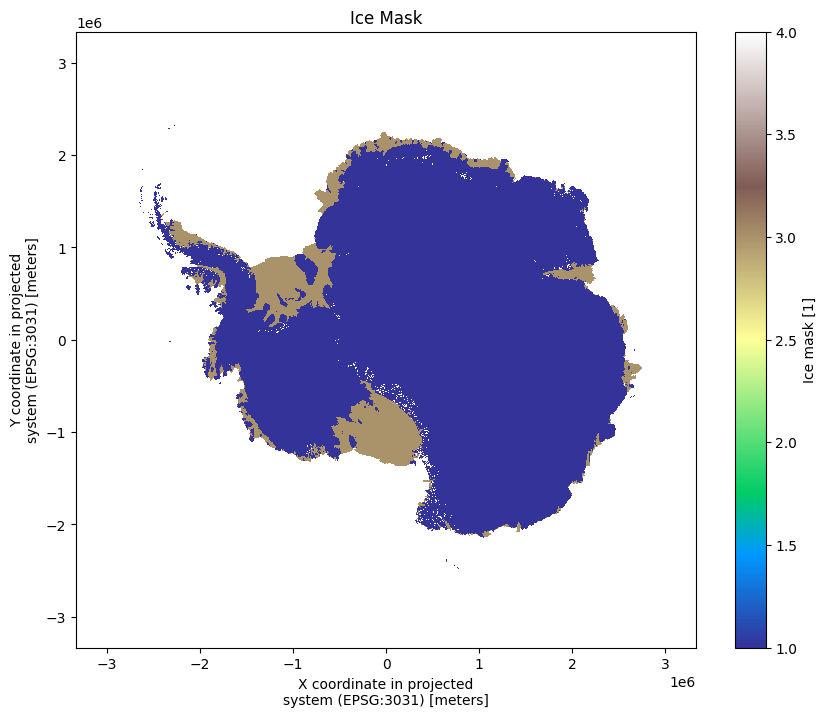

In [13]:
import xarray as xr
import matplotlib.pyplot as plt

# Load dataset
ds = xr.open_dataset("bedmap3.nc")

# Subset or downsample (e.g., every 10th point)
bed = ds['mask'][::10, ::10]

# Plot
plt.figure(figsize=(10, 8))
bed.plot(cmap='terrain')
plt.title('Ice Mask')
plt.show()
